In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from astropy.io import fits
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ============================================================================
# Configuration
# ============================================================================

BASE_PATHS = {
    'lm_mcmc': '../../../NA_zenodo/lens_modelling_products_suppfig1/', 
    # Directory containing the lens-modelling MCMC chains and related products for the lenses shown in Supplementary Fig. 1
}

MODEL = 'bkpl_bk'

# ============================================================================
# Data Loading
# ============================================================================

def read_col(filename):
    """Read a column from a whitespace-separated text file."""
    return pd.read_csv(filename, sep=r'\s+', header=None, comment='#')

def read_fits_table(filepath, ext=1):
    """Read a FITS table from a specified HDU extension."""
    with fits.open(filepath) as hdul:
        return hdul[ext].data

def read_fits_image(filepath, ext=0):
    """Read a FITS image from a specified HDU extension."""
    with fits.open(filepath) as hdul:
        return hdul[ext].data

In [3]:
# get the names with survey name and lens name
jdata = read_col('../../data/Supplementary_table3_lens_sample.dat')
jnames = jdata[0].values
snames = jdata[1].values
true_names = snames+' '+jnames

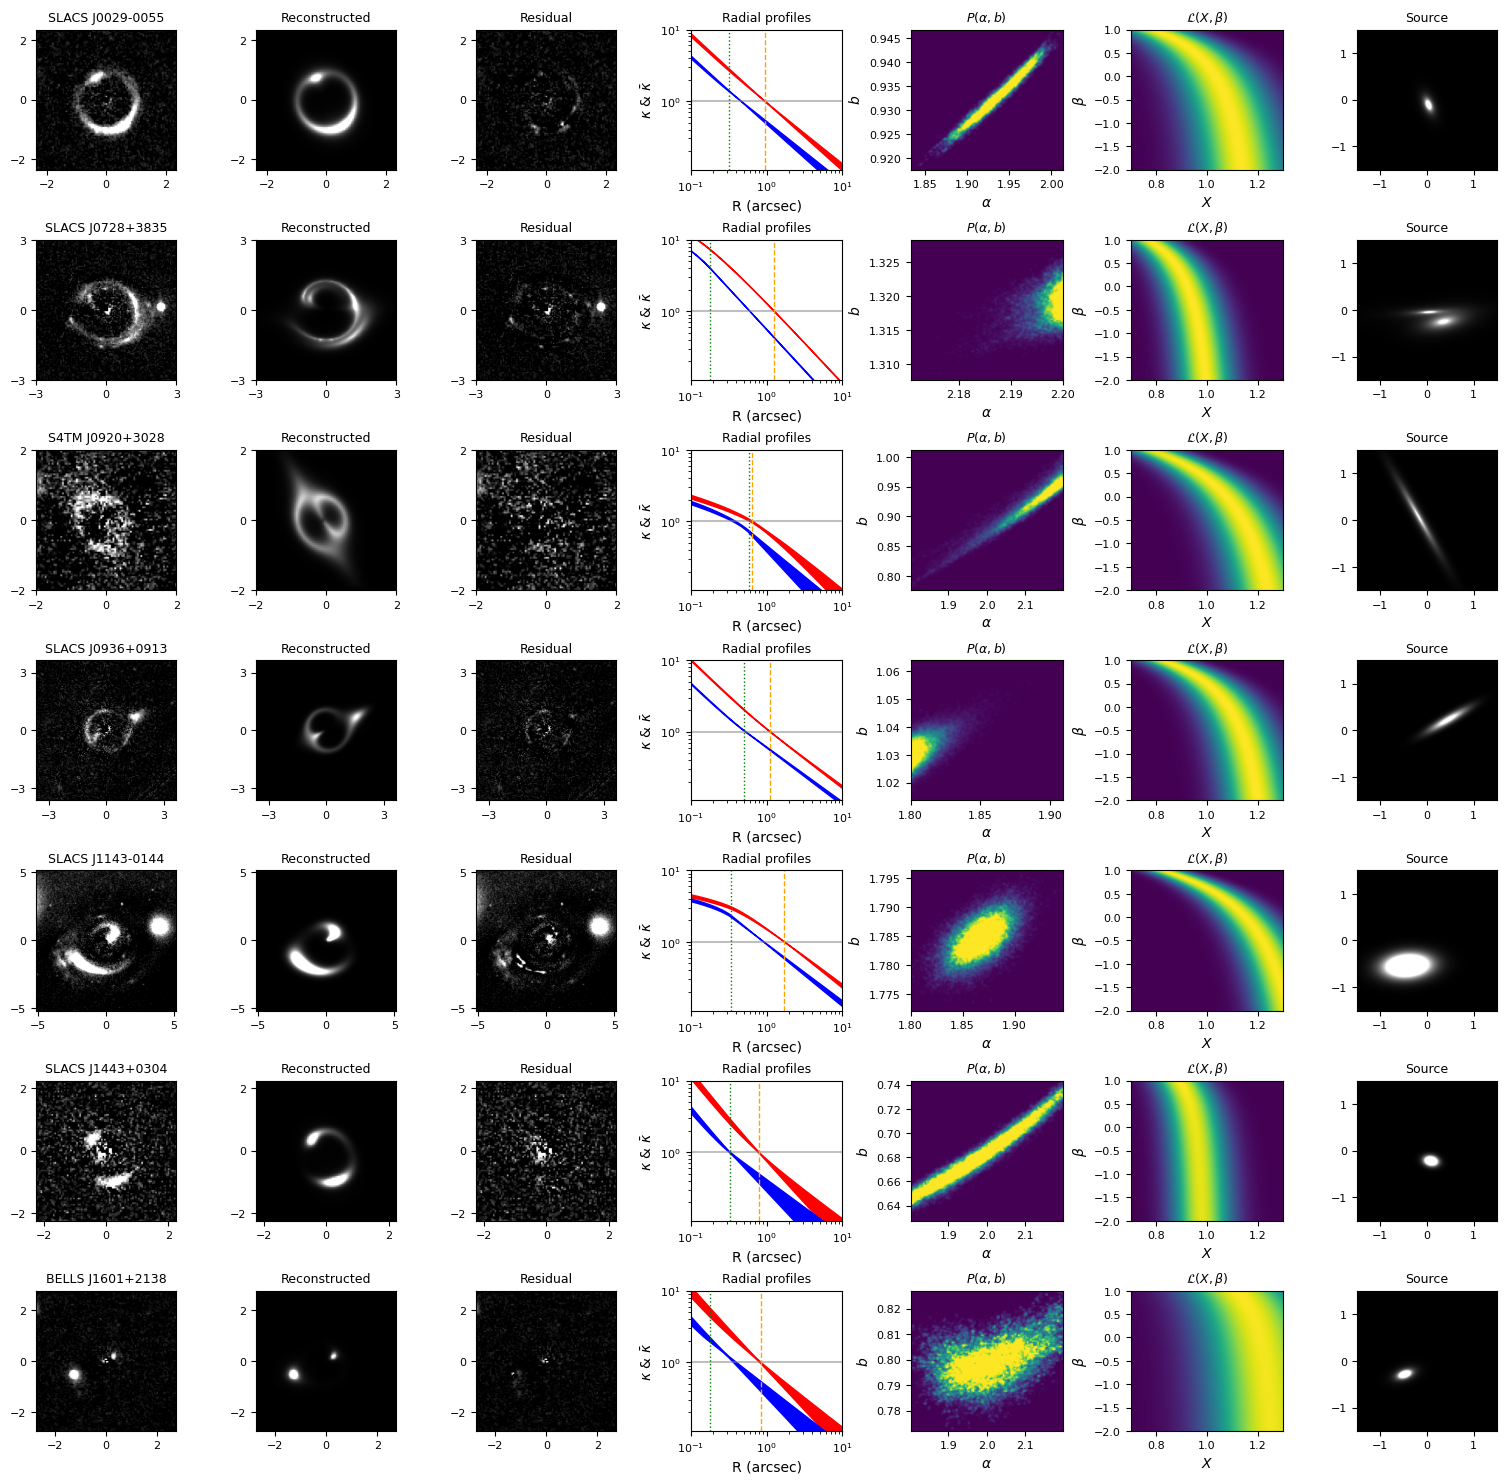

In [4]:
#Load number-of-sources flag mapping (first column used as names)
nsrc_data = read_col('../../data/nsource_flag.dat')
names = nsrc_data[0].values
nsrc_dict = {nsrc_data[0].iloc[i]: int(nsrc_data[1].iloc[i]) for i in range(len(nsrc_data))}

#sl_list = [1,14,17,26,28,57,79,93,105,118] 
sl_list = [1,14,26,28,57,79,118] #
sl_names = names[sl_list]
tr_names = true_names[sl_list]
n_obj =  len(sl_names)
# ============================================================================
# Plot Configuration
# ============================================================================
#n_obj = CASES #len(name),total rows in GridSpec
h_per_row = 2.6   # height per row
w = 19 # total width

fig = plt.figure(figsize=(w, h_per_row * n_obj))
gs = GridSpec(n_obj, 7, figure=fig, hspace=0.5, wspace=0.45) 

# --- Font settings (global) ---
import matplotlib as mpl
mpl.rcParams['xtick.labelsize'] = 8   # tick label font size (x)
mpl.rcParams['ytick.labelsize'] = 8   # tick label font size (y)
mpl.rcParams['axes.titlesize'] = 9     # axes title font size

# ============================================================================
# Main Loop: Plot multiple sub-panels per object
# ============================================================================
for obj_id in range(n_obj):
    name = sl_names[obj_id]
    n_sources = nsrc_dict.get(name, 1)
    suffix = '_a1822ts' if n_sources == 2 else '_a1822'
    
    # Build file paths
    path_mcmc = f'{BASE_PATHS["lm_mcmc"]}bkpl_bk_a1822/{name}_{MODEL}{suffix}.fits'
    path_best_kappa = f'{BASE_PATHS["lm_mcmc"]}kappa_r/best_kappa_r_{name}{suffix}.fits'
    path_kappa = f'{BASE_PATHS["lm_mcmc"]}kappa_r/kappa_r_{name}{suffix}.fits'
    #path_biz = f'{BASE_PATHS["sl_obs"]}SL_{name}_biz.fits'
    
    path_pab = f'{BASE_PATHS["lm_mcmc"]}pab/tsc_ab_{name}{suffix}.fits'
    path_pxb = f'../../data/xbeta_likelihood_maps/{name}.fits'
    
    # Load MCMC data
    mcmc_table = read_fits_table(path_mcmc, 2)
    lpar = mcmc_table['lpar']
    # Extract parameters
    b, q = lpar[0], lpar[4]
    a, ac, rc, mb = lpar[5] + 1.0, lpar[6] + 1.0, lpar[7], lpar[8]
    
    # Load best kappa information
    best_kappa = read_fits_table(path_best_kappa, 1)
    fmkap, bein = best_kappa['mkap_best'][0], best_kappa['bein_best'][0]
    
    #Load kappa samples and compute percentiles
    kappa_table = read_fits_table(path_kappa, 1)
    mkap_arr = kappa_table['mkap_arr'][0]
    ras = np.logspace(np.log10(0.1), np.log10(10), 25) # Radius grid used for the profile plot
    # emkap = np.sqrt(np.var(mkap_arr, axis=0))
    # 95% credible interval (percentile range)
    mkap_low = np.percentile(mkap_arr, 2.5, axis=0)   # shape: (25,)
    mkap_high = np.percentile(mkap_arr, 97.5, axis=0) # shape: (25,)

    kap_arr = kappa_table['kap_arr'][0]
    kap_low = np.percentile(kap_arr, 2.5, axis=0)   # shape: (25,)
    kap_high = np.percentile(kap_arr, 97.5, axis=0) # shape: (25,)

    # Load image data (for panel 0-2, 7)
    img = read_fits_image(path_mcmc, 4)
    bsp = read_fits_image(path_mcmc, 6)
    fit = read_fits_image(path_mcmc, 7)
    src = read_fits_image(path_mcmc, 8)

    # Compute extent for image coordinate mapping
    ny, nx = img.shape
    dx = dy = 0.05
    cx = (nx - 1) / 2.0
    cy = (ny - 1) / 2.0
    x0, x1 = (0 - cx) * dx, (0 + cx) * dx
    y0, y1 = (0 - cy) * dy, (0 + cy) * dy

    vmin, vmax = -0.,0.1
    # ============================================================
    # Panel 0: Image - Background
    # ============================================================
    ax = fig.add_subplot(gs[obj_id:(obj_id+1), 0])
    ax.imshow(img - bsp, cmap='grey', vmin=vmin, vmax=vmax, extent=[x0, x1, y0, y1], origin='lower') #cmap='magma'
    # ax.set_title(f'{name} (Image-BG)', fontsize=8)
    #ax.set_title(f'{name}')
    ax.set_title(f'{tr_names[obj_id]}')
    # Set ticks (attempt to match displayed region)
    ticks = np.arange(x0, x1+0.01, x1//1,dtype=int)
    x_ticks = ticks[(ticks >= x0) & (ticks <= x1)]
    y_ticks = ticks[(ticks >= y0) & (ticks <= y1)]
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)

    # ============================================================
    # Panel 1: Reconstructed model
    # ============================================================
    ax = fig.add_subplot(gs[obj_id:(obj_id+1), 1])
    ax.imshow(fit, cmap='grey', vmin=vmin, vmax=vmax, extent=[x0, x1, y0, y1], origin='lower')
    ax.set_title(f'Reconstructed')
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    
    # ============================================================
    # Panel 2: Residual = Image - BG - Model
    # ============================================================
    ax = fig.add_subplot(gs[obj_id:(obj_id+1), 2])
    ax.imshow(img - bsp - fit, cmap='grey', vmin=vmin, vmax=vmax, extent=[x0, x1, y0, y1], origin='lower')
    ax.set_title(f'Residual')
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)
    
    # ============================================================
    # Panel 3: Mean kappa(R) with 95% CI band
    # ============================================================
    ax = fig.add_subplot(gs[obj_id:(obj_id+1), 3])
    # ax.loglog(ras, fmkap, 'b-', linewidth=1)
    #ax.fill_between(ras, fmkap - 3*emkap, fmkap + 3*emkap, alpha=0.3)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.fill_between(ras, mkap_low, mkap_high, alpha=1.0, color='red')
    ax.fill_between(ras, kap_low, kap_high, alpha=1.0, color='blue')
    # Reference lines and parameter markers
    ax.axhline(1.0, color='gray', linestyle='-', alpha=0.5)
    ax.axvline(rc, color='green', linestyle=':', linewidth=1.0)
    ax.axvline(bein, color='orange', linestyle='--', linewidth=1.0)
    ax.set_xlim([0.1, 10])
    ax.set_ylim([0.11, 10])
    ax.set_xlabel(r'R (arcsec)')
    ax.set_ylabel(r'$\kappa ~&~ \bar{\kappa}$')
    ax.set_title(r'Radial profiles')
    
    #print(f"{name}: R_E = {bein:.4f} arcsec")

    # ============================================================
    # Panel 4: P(a, b)
    # ============================================================
    pab_table = read_fits_image(path_pab, 1)  
    pab = pab_table['P12'][0]
    xG = pab_table['xG'][0][0]
    yG = pab_table['yG'][0][:,0]
    ax = fig.add_subplot(gs[obj_id:(obj_id+1), 4])

    im = ax.imshow(
        pab,
        origin='lower',
        extent=[
            np.nanmin(xG), np.nanmax(xG),
            np.nanmin(yG), np.nanmax(yG)
        ],
        aspect='auto',
        interpolation='bilinear',
        cmap='viridis',
        vmin=0,
        vmax=np.nanmax(pab) * 0.4,
        rasterized=True
    )    
    ax.set_xlabel(r'$\alpha$')
    ax.set_ylabel(r'$b$')
    ax.set_title(r'$P(\alpha,b)$')
    #plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlim(max(np.nanmin(xG), 1.8), min(np.nanmax(xG), 2.2))

    # ============================================================
    # Panel 5: L(X, beta)
    # ============================================================
    pxb = read_fits_image(path_pxb, 0)  
    xG = read_fits_image(path_pxb, 1)
    yG = read_fits_image(path_pxb, 2)
    ax = fig.add_subplot(gs[obj_id:(obj_id+1), 5])

    im = ax.imshow(
        pxb,
        origin='lower',
        extent=[
            np.nanmin(xG), np.nanmax(xG),
            #np.nanmin(yG), np.nanmax(yG)
            -2,1
        ],
        aspect='auto',
        interpolation='bilinear',
        cmap='viridis',
        vmin=0,
        vmax=np.nanmax(pxb),
        rasterized=True
    )
    ax.set_xlabel(r'$X$')
    ax.set_ylabel(r'$\beta$')
    ax.set_title(r'$\mathcal{L}(X,\beta)$')
    #plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)    
    
    # ============================================================
    # Panel 6: Cropped source image (center 300x300)
    # ============================================================
    ny, nx = src.shape
    dx = dy = 0.01
    cx = (nx - 1) / 2.0
    cy = (ny - 1) / 2.0
    # Crop center 300x300
    size = 300
    half_size = size // 2
    src_crop = src[int(cy - half_size):int(cy + half_size + 1),
                int(cx - half_size):int(cx + half_size + 1)]

    # Physical coordinate range corresponding to the cropped image
    x0,x1 = -half_size * dx, half_size * dx
    y0,y1 = -half_size * dy, half_size * dy

    ax = fig.add_subplot(gs[obj_id:(obj_id+1), 6])
    ax.imshow(src_crop, cmap='grey', vmin=vmin, vmax=vmax, extent=[x0, x1, y0, y1], origin='lower')
    ax.set_title(r'Source')
    # ax.axis('off')
    ticks = np.arange(x0, x1+0.1, x1//1,dtype=int)
    x_ticks = ticks[(ticks >= x0) & (ticks <= x1)]
    y_ticks = ticks[(ticks >= y0) & (ticks <= y1)]
    ax.set_xticks(x_ticks)
    ax.set_yticks(y_ticks)

# plt.suptitle('MCMC Analysis: Image & Kappa Profiles', fontsize=10)
plt.savefig('sup_fig1_abxbeta7.pdf', dpi=350, bbox_inches='tight')
#plt.savefig('sup_fig1_abxbeta7.png', dpi=350, bbox_inches='tight')
plt.show()